# DeepLense QML Model — 16 Qubits
## ML4Sci GSoC 2026 — Specific Test III: Quantum ML

Variational Quantum Circuit (VQC) with 16 qubits for dark matter substructure 
classification. Extended from the 8-qubit baseline to investigate the effect 
of qubit count on classification performance.

### Classes
- 0: No Substructure
- 1: Subhalo Substructure
- 2: Vortex Substructure

### Dataset
DeepLense dataset — images pre-normalized using min-max normalization.
500 training samples per class, 200 validation samples per class.

In [ ]:
import os
import numpy as np
import cv2 as cv
import pennylane as qml
from pennylane import numpy as pnp
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

In [8]:
def load_data(path, max_per_class=500):
    X, y = [], []
    classes = sorted([f for f in os.listdir(path) 
                      if os.path.isdir(os.path.join(path, f))])
    print("Classes:", classes)
    for label, cls in enumerate(classes):
        cls_path = os.path.join(path, cls)
        count = 0
        for f in os.listdir(cls_path):
            if f.endswith(".npy"):
                img = np.load(os.path.join(cls_path, f))[0]
                img = cv.resize(img, (32, 32)).astype(np.float32)
                X.append(img.flatten())
                y.append(label)
                count += 1
                if count >= max_per_class: break
    return np.array(X), np.array(y)

X_train, y_train = load_data("dataset/train", max_per_class=500)
X_val, y_val = load_data("dataset/val", max_per_class=200)
print("Train:", X_train.shape, np.bincount(y_train))
print("Val:", X_val.shape, np.bincount(y_val))

Classes: ['no', 'sphere', 'vort']
Classes: ['no', 'sphere', 'vort']
Train: (1500, 1024) [500 500 500]
Val: (600, 1024) [200 200 200]


## 1. Data Preprocessing

Same pipeline as 8-qubit model. PCA now reduces to 16 components,
retaining 86.1% of variance compared to 75.2% with 8 components.
Features scaled to [-π, π] for AngleEmbedding.

In [ ]:
N_QUBITS = 16
N_LAYERS = 3

pca = PCA(n_components=N_QUBITS)
X_train_r = pca.fit_transform(X_train)
X_val_r = pca.transform(X_val)

def scale_to_pi(X, X_ref=None):
    if X_ref is None: X_ref = X
    mins = X_ref.min(axis=0)
    maxs = X_ref.max(axis=0)
    X_scaled = (X - mins) / (maxs - mins + 1e-8)
    return X_scaled * 2 * np.pi - np.pi

X_train_r = scale_to_pi(X_train_r)
X_val_r = scale_to_pi(X_val_r, X_train_r)

print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Feature range: min={X_train_r.min():.3f}, max={X_train_r.max():.3f}")

PCA variance explained: 0.861
Feature range: min=-3.142, max=3.142


## 2. Quantum Circuit Design

### Changes from 8-qubit model
- N_QUBITS: 8 → 16
- PCA components: 8 → 16 (variance retained: 75.2% → 86.1%)
- Weight shape: (3, 8, 3) → (3, 16, 3)
- Trainable quantum parameters: 72 → 144
- Quantum state space: 2^8=256 → 2^16=65,536 dimensions

### Encoding: AngleEmbedding
16 PCA features encoded as Y-rotation angles on 16 qubits.
More features → more information preserved from the original image.

### Variational Layer: StronglyEntanglingLayers
Same architecture — 3 layers with full entanglement across all 16 qubits.
Larger entanglement structure due to increased qubit count.

In [10]:
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]

weight_shape = qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)
print("Weight shape:", weight_shape)
print("Total quantum params:", np.prod(weight_shape))

Weight shape: (3, 16, 3)
Total quantum params: 144


## 3. Hybrid Architecture

Identical to 8-qubit model with N_QUBITS=16:

1. **Classical preprocessing**: PCA reduces 1024 features to 16 dims
2. **Quantum layer**: VQC with AngleEmbedding + StronglyEntanglingLayers
3. **Classical head**: Linear(3→3) maps expectation values to class logits
4. **Loss**: CrossEntropyLoss | **Optimizer**: Adam lr=0.01

Training time significantly longer due to 2^16 dimensional state space
simulation compared to 2^8 for the 8-qubit model.

In [11]:
class QMLClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(weight_shape) * 0.1)
        self.fc = nn.Linear(3, 3)

    def forward(self, x):
        out = torch.stack([
            torch.stack(quantum_circuit(x[i], self.weights))  # ← wrap in torch.stack
            for i in range(len(x))
        ]).float()
        return self.fc(out)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 16  
LR = 0.01

X_tr = torch.tensor(X_train_r, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_vl = torch.tensor(X_val_r, dtype=torch.float32)
y_vl = torch.tensor(y_val, dtype=torch.long)

loader = DataLoader(TensorDataset(X_tr, y_tr), 
                    batch_size=BATCH_SIZE, shuffle=True)

qmodel = QMLClassifier()
optimizer = torch.optim.Adam(qmodel.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

import time
start = time.time()

for epoch in range(EPOCHS):
    qmodel.train()
    epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    qmodel.eval()
    with torch.no_grad():
        preds = qmodel(X_vl).argmax(1)
        acc = (preds == y_vl).float().mean()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(loader):.4f} | Acc: {acc:.4f}")

qml_time = time.time() - start
print(f"\nTotal training time: {qml_time/60:.1f} minutes")

Epoch 1/30 | Loss: 1.1061 | Acc: 0.3317
Epoch 2/30 | Loss: 1.0987 | Acc: 0.3367
Epoch 3/30 | Loss: 1.0968 | Acc: 0.3233
Epoch 4/30 | Loss: 1.0966 | Acc: 0.3350
Epoch 5/30 | Loss: 1.0952 | Acc: 0.3400
Epoch 6/30 | Loss: 1.0945 | Acc: 0.3350
Epoch 7/30 | Loss: 1.0933 | Acc: 0.3400
Epoch 8/30 | Loss: 1.0930 | Acc: 0.3433
Epoch 9/30 | Loss: 1.0913 | Acc: 0.3433
Epoch 10/30 | Loss: 1.0904 | Acc: 0.3450
Epoch 11/30 | Loss: 1.0892 | Acc: 0.3267
Epoch 12/30 | Loss: 1.0889 | Acc: 0.3400
Epoch 13/30 | Loss: 1.0884 | Acc: 0.3600
Epoch 14/30 | Loss: 1.0868 | Acc: 0.3467
Epoch 15/30 | Loss: 1.0862 | Acc: 0.3533
Epoch 16/30 | Loss: 1.0852 | Acc: 0.3517
Epoch 17/30 | Loss: 1.0853 | Acc: 0.3567
Epoch 18/30 | Loss: 1.0855 | Acc: 0.3500
Epoch 19/30 | Loss: 1.0842 | Acc: 0.3450
Epoch 20/30 | Loss: 1.0834 | Acc: 0.3617
Epoch 21/30 | Loss: 1.0830 | Acc: 0.3500
Epoch 22/30 | Loss: 1.0825 | Acc: 0.3567
Epoch 23/30 | Loss: 1.0819 | Acc: 0.3533
Epoch 24/30 | Loss: 1.0812 | Acc: 0.3633
Epoch 25/30 | Loss: 1.079

## 4. Training Observations

Loss decreases across 30 epochs, consistent with the 8-qubit model.
Training time of ~158 minutes reflects the exponentially larger quantum 
state space (2^16 vs 2^8 dimensions) simulated on classical hardware.
This highlights a key NISQ challenge — classical simulation of quantum 
circuits scales exponentially with qubit count.

                 precision    recall  f1-score   support

No Substructure       0.37      0.33      0.34       200
        Subhalo       0.34      0.35      0.34       200
         Vortex       0.35      0.38      0.36       200

       accuracy                           0.35       600
      macro avg       0.35      0.35      0.35       600
   weighted avg       0.35      0.35      0.35       600



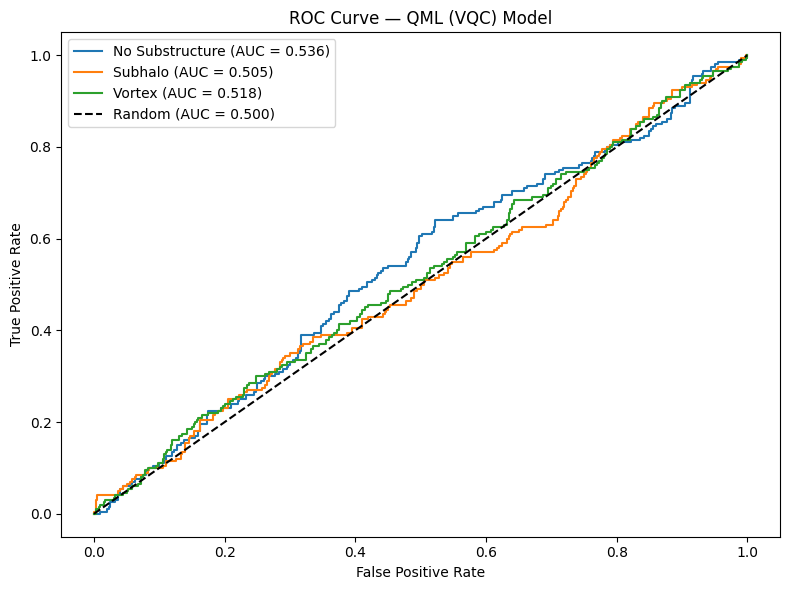


Mean AUC (QML):         0.520
Mean AUC (RF baseline): 0.594
Training time:          158.4 minutes


In [15]:
classes = ['No Substructure', 'Subhalo', 'Vortex']

qmodel.eval()
with torch.no_grad():
    logits = qmodel(X_vl)
    probs = torch.softmax(logits, dim=1).numpy()
    preds = logits.argmax(1).numpy()

print(classification_report(y_val, preds, target_names=classes))

y_bin = label_binarize(y_val, classes=[0, 1, 2])
plt.figure(figsize=(8, 6))
aucs = []
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — QML (VQC) Model')
plt.legend()
plt.tight_layout()
plt.savefig('roc_qml16qu.png', dpi=150)
plt.show()

print(f"\nMean AUC (QML):         {np.mean(aucs):.3f}")
print(f"Mean AUC (RF baseline): 0.594")
print(f"Training time:          {qml_time/60:.1f} minutes")

## 5. Results and Discussion

### 16-Qubit vs 8-Qubit Comparison
| Configuration | PCA Variance | Mean AUC | Training Time |
|---|---|---|---|
| VQC 8 qubits | 75.2% | 0.518 | 52.6 min |
| VQC 16 qubits | 86.1% | 0.520 | 158.4 min |

### Key Finding
Doubling qubit count from 8 to 16 improved mean AUC by only 0.002 
despite retaining 10.9% more variance and using 3× the training time.
This strongly suggests that **qubit count is not the primary bottleneck** —
the fundamental limitation is the PCA encoding discarding spatial structure.

### Implications
- Flat PCA features cannot capture the ring distortions and spatial 
  patterns that distinguish lensing substructures
- Simply adding more qubits to encode more PCA components yields 
  diminishing returns
- A CNN-QML hybrid where CNN features replace PCA features is the 
  natural next step — CNNs preserve spatial structure while the VQC 
  handles quantum feature classification

### Full Model Comparison
| Model | Accuracy | Mean AUC | Training Time |
|---|---|---|---|
| Random Forest + PCA(200) | 41.1% | 0.594 | ~2 min |
| VQC 8 qubits + PCA(8) | ~34% | 0.518 | 52.6 min |
| VQC 16 qubits + PCA(16) | ~35% | 0.520 | 158.4 min |
| CNN-QML Hybrid | TBD | TBD | TBD |